In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

filename = "data/20260402_195037_free-space/simulation_results.pkl"
#filename = "data/20260402_195641_integrated/simulation_results.pkl"

with open(filename, 'rb') as fp:
        d_result = pickle.load(fp)

Us = d_result['axes']['Us']
theta_outs = d_result['axes']['theta_outs']
gammas = d_result['axes']['gammas']
phi_LO = d_result['axes']['phis']

print(f"saved keys {list(d_result.keys())}")
print(f"saved axes {list(d_result['axes'].keys())}")

U_print = [f"{v:.1e}" for v in d_result['axes']['Us']]
print(f"Us: {U_print}")

theta_outs_print = [rf"{v/np.pi:.2f}" for v in d_result['axes']['theta_outs']]
print(f"theta_outs: pi x {theta_outs_print}")

gamma_print = [f"{v:.1f}" for v in d_result['axes']['gammas']]
print(f"gammas: {gamma_print}")

saved keys ['axes', 'n1s', 'n2s', 'g2_11s', 'g2_22s', 'g2_12s']
saved axes ['Us', 'theta_outs', 'gammas', 'phis']
Us: ['1.0e-03', '1.7e-03', '2.8e-03', '4.6e-03', '7.7e-03', '1.3e-02', '2.2e-02', '3.6e-02', '6.0e-02', '1.0e-01']
theta_outs: pi x ['0.00', '0.02', '0.04', '0.06', '0.08', '0.10', '0.12', '0.14', '0.16', '0.18', '0.20', '0.22', '0.24', '0.26', '0.28', '0.30', '0.32', '0.34', '0.36', '0.38', '0.40', '0.42', '0.44', '0.46', '0.48', '0.50']
gammas: ['0.0', '0.1', '0.2', '0.3', '0.4', '0.6', '0.7', '0.8', '0.9', '1.0']


# plot to compare Us

U = [0.0016681  0.00464159 0.05994843], theta = 0.2pi, gamma = 0.0
min g2: 0.9747201089451087
min g2: 0.930722731084396
min g2: 0.37123351591075393


/tmp/ipykernel_3464292/3016489721.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


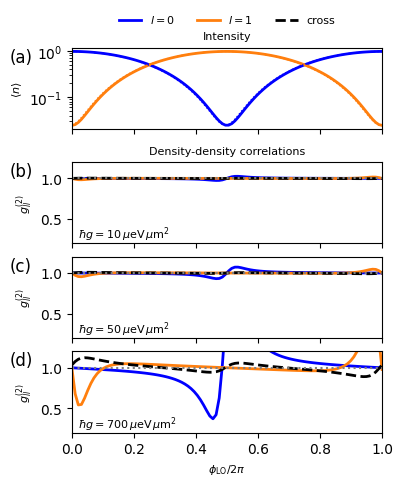

In [4]:
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors

iUs = [1, 3, 8]
iT = 10
iG = 0

g2_lim = [0.2, 1.2]

linewidths = [2, 1, 1]
linestyles = ['-', '--', ':']

print(f"U = {Us[iUs]}, theta = {theta_outs[iT]/np.pi}pi, gamma = {gammas[iG]}")

x_axes = phi_LO / 2. / np.pi

# ------------------------------------------------------------------
# Figure + GridSpec  (mirrors the first figure exactly)
# ------------------------------------------------------------------
fig = plt.figure(figsize=(4, 5))
gs  = GridSpec(
        nrows=5, ncols=1,
        height_ratios=[1, 0.08, 1, 1, 1],
        hspace=0.2
     )

ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[2, 0])
ax2 = fig.add_subplot(gs[3, 0])
ax3 = fig.add_subplot(gs[4, 0])
ax  = [ax0, ax1, ax2, ax3]

# ------------------------------------------------------------------
# Panel (a) – intensities  ⟨n⟩  for all three U values
# ------------------------------------------------------------------
for iU, linewidth, linestyle in zip(iUs, linewidths, linestyles):
    ax[0].semilogy(x_axes, d_result['n1s'][iU, iT, iG], "b",
                   linewidth=linewidth, linestyle=linestyle)
    ax[0].semilogy(x_axes, d_result['n2s'][iU, iT, iG], "tab:orange",
                   linewidth=linewidth, linestyle=linestyle)

ax[0].tick_params(axis='x', labelbottom=False)
ax[0].set_ylabel(r"$\langle n \rangle$", fontsize=8)
ax[0].set_title("Intensity", fontsize=8)
#ax[0].grid(True)

# ------------------------------------------------------------------
# Panels (b–d) – g²  for each U value
# ------------------------------------------------------------------
U_labels = [
    fr'$U = {Us[iUs[0]]:.0f}$',
    fr'$U = {Us[iUs[1]]:.0f}$',
    fr'$U = {Us[iUs[2]]:.0f}$',
]

for i, (panel_ax, iU, u_label) in enumerate(zip(ax[1:], iUs, U_labels), start=1):
    panel_ax.plot(x_axes, d_result['g2_11s'][iU, iT, iG], "b",        linewidth=2, linestyle='-')
    panel_ax.plot(x_axes, d_result['g2_22s'][iU, iT, iG], "tab:orange", linewidth=2, linestyle='-')
    panel_ax.plot(x_axes, d_result['g2_12s'][iU, iT, iG], "k",        linewidth=2, linestyle='--')
    panel_ax.set_ylabel(r"$g^{(2)}_{ll}$", fontsize=8)
    panel_ax.set_ylim(g2_lim)
    panel_ax.axhline(1., linestyle=":", color="grey")
    #panel_ax.grid(True)
    if i < 3:
        panel_ax.tick_params(axis='x', labelbottom=False)
    print(f"min g2: {min([np.min(d_result['g2_11s'][iU, iT, iG]), np.min(d_result['g2_22s'][iU, iT, iG])])}")

ax[3].set_xlabel(r"$\phi_\text{LO}/2\pi$", fontsize=8)
ax[1].set_title("Density-density correlations", fontsize=8)

# ------------------------------------------------------------------
# Common x limits / y limits for g² panels
# ------------------------------------------------------------------
for a in ax:
    a.set_xlim([x_axes[0], x_axes[-1]])

# ------------------------------------------------------------------
# Panel labels (a) (b) (c) (d)
# ------------------------------------------------------------------
panel_labels = ['(a)', '(b)', '(c)', '(d)']
for i, a in enumerate(ax):
    a.text(-0.2, 1., panel_labels[i],
           transform=a.transAxes, fontsize=12, va='top', ha='left')

# ------------------------------------------------------------------
# U-value annotation inside each g² panel
# ------------------------------------------------------------------
extra_text = [
    '',#r'Intensities: $\langle n_l \rangle$',
    r'$\hbar g = 10\,\mu\text{eV}\,\mu\text{m}^2$',
    r'$\hbar g = 50\,\mu\text{eV}\,\mu\text{m}^2$',
    r'$\hbar g = 700\,\mu\text{eV}\,\mu\text{m}^2$'
]
for i, a in enumerate(ax):
    a.text(0.02, 0.23, extra_text[i],
           transform=a.transAxes, fontsize=8, va='top', ha='left')

# ------------------------------------------------------------------
# Legend: colours = mode (blue/orange), linestyles = U values
# ------------------------------------------------------------------
from matplotlib.lines import Line2D

color_handles = [
    Line2D([0], [0], color='b',           lw=2, label=r'$l=0$'),
    Line2D([0], [0], color='tab:orange',  lw=2, label=r'$l=1$'),
    Line2D([0], [0], color='k',           lw=2, linestyle='--', label=r'cross'),
]

ax[0].legend(
    handles=color_handles,
    loc='lower center',
    bbox_to_anchor=(0.5, 1.15),
    ncol=3,
    frameon=False,
    fontsize=8
)

fig.subplots_adjust(hspace=0.)
fig.tight_layout()
plt.show()

U = [0.0016681  0.00464159 0.05994843], theta = 0.22pi, gamma = 0.0


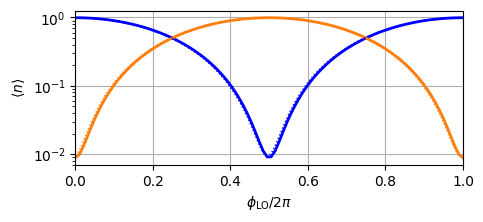

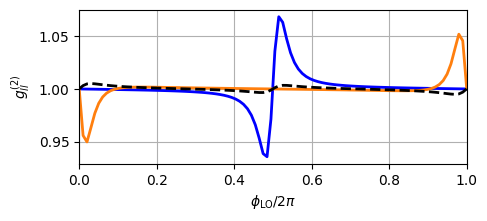

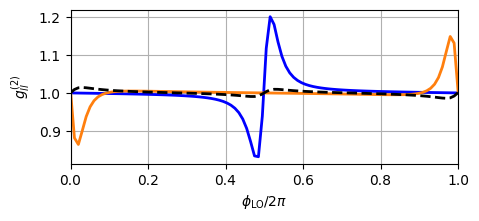

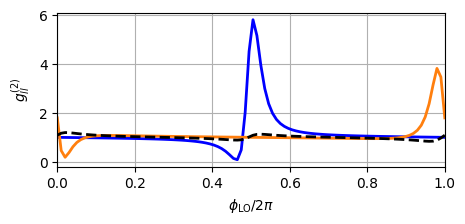

In [5]:
iUs = [1, 3, 8]
iT = 11
iG = 0

linewidths = [2, 1, 1]
linestyles = ['-', '--', ":"]

print(f"U = {Us[iUs]}, theta = {theta_outs[iT]/np.pi}pi, gamma = {gammas[iG]}")

x_axes = phi_LO/2. / np.pi
# figure ns
plt.figure(figsize=(5,2))
for iU, linewidth, linestyle in zip(iUs, linewidths, linestyles):
    plt.semilogy(x_axes, d_result['n1s'][iU,iT,iG], "b", linewidth=linewidth, linestyle=linestyle)
    plt.semilogy(x_axes, d_result['n2s'][iU,iT,iG], "tab:orange", linewidth=linewidth, linestyle=linestyle)
    plt.ylabel(r"$\langle n \rangle$")

plt.xlim([x_axes[0], x_axes[-1]])
plt.xlabel(r"$\phi_\text{LO}/2\pi$")
plt.grid(True)
plt.show()


for iU in iUs:
    linestyle = linestyles[0]
    linewidth = linewidths[0]

    # figure g2s
    plt.figure(figsize=(5,2))
    plt.plot(x_axes, d_result['g2_11s'][iU,iT,iG], "b", linewidth=linewidth, linestyle=linestyle)
    plt.plot(x_axes, d_result['g2_22s'][iU,iT,iG], "tab:orange", linewidth=linewidth, linestyle=linestyle)
    plt.plot(x_axes, d_result['g2_12s'][iU,iT,iG], "k", linewidth=linewidth, linestyle="--")
    

    plt.xlim([x_axes[0], x_axes[-1]])
    #plt.ylim([0.5,1.1])
    plt.xlabel(r"$\phi_\text{LO}/2\pi$")
    plt.ylabel(r"$g^{(2)}_{ll}$")
    plt.grid(True)
    plt.show()

# plot to compare gammas

U = 0.021544346900318832, theta = 0.18pi, gammas = [0.         0.11111111 0.22222222 0.33333333]


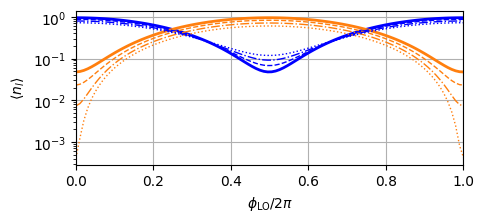

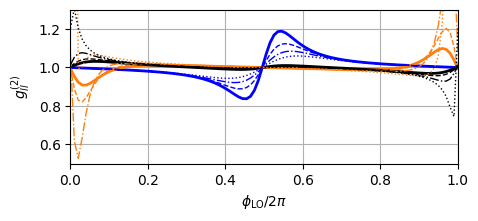

In [12]:
iU = 6
iT = 9
iGs = [0, 1, 2, 3]

linewidths = [2, 1, 1, 1]
linestyles = ['-', '--', "-.",":"]

print(f"U = {Us[iU]}, theta = {theta_outs[iT]/np.pi}pi, gammas = {gammas[iGs]}")

x_axis = phi_LO / 2 / np.pi

# figure ns
plt.figure(figsize=(5,2))
for iG, linewidth, linestyle in zip(iGs, linewidths, linestyles):
    plt.semilogy(x_axis, d_result['n1s'][iU,iT,iG], "b", linewidth=linewidth, linestyle=linestyle)
    plt.semilogy(x_axis, d_result['n2s'][iU,iT,iG], "tab:orange", linewidth=linewidth, linestyle=linestyle)


plt.xlim([x_axis[0], x_axis[-1]])
plt.xlabel(r"$\phi_\text{LO}/2\pi$")
plt.ylabel(r"$\langle n_l \rangle$")
plt.grid(True)
plt.show()


# figure g2s
plt.figure(figsize=(5,2))
for iG, linewidth, linestyle in zip(iGs, linewidths, linestyles):
    plt.plot(x_axis, d_result['g2_11s'][iU,iT,iG], "b", linewidth=linewidth, linestyle=linestyle)
    plt.plot(x_axis, d_result['g2_22s'][iU,iT,iG], "tab:orange", linewidth=linewidth, linestyle=linestyle)
    plt.plot(x_axis, d_result['g2_12s'][iU,iT,iG], "k", linewidth=linewidth, linestyle=linestyle)


plt.xlim([x_axis[0], x_axis[-1]])
plt.ylim([0.5,1.3])
plt.xlabel(r"$\phi_\text{LO}/2\pi$")
plt.ylabel(r"$g^{(2)}_{ll}$")
plt.grid(True)
plt.show()

In [6]:
gammas * 8.686

array([0.        , 0.96511111, 1.93022222, 2.89533333, 3.86044444,
       4.82555556, 5.79066667, 6.75577778, 7.72088889, 8.686     ])

# pcolor phi_LO, theta_out

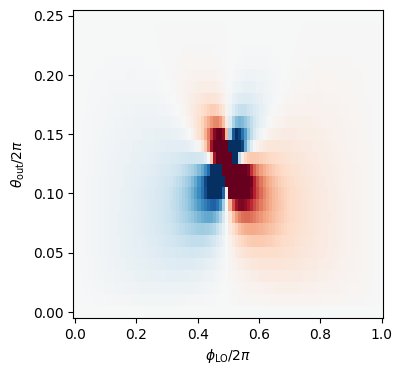

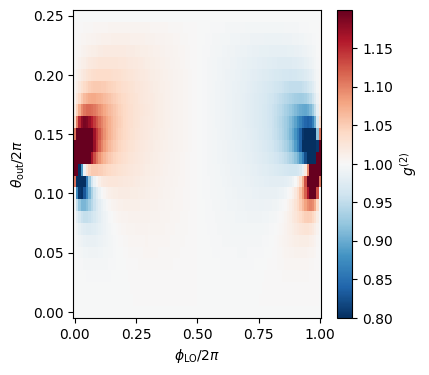

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

iU = 6
iG = 0
g2_max = 1.2
g2_min = 0.8

dat1 = np.maximum(np.minimum(d_result['g2_11s'][iU, :, iG, :], g2_max), g2_min)
dat2 = np.maximum(np.minimum(d_result['g2_22s'][iU, :, iG, :], g2_max), g2_min)
#dat = np.log10(d_result['g2_11s'][iU, :, iG, :])

x_axis = phi_LO / 2 / np.pi
y_axis = theta_outs / 2 / np.pi

# Diverging norm centered at 1
norm = mcolors.TwoSlopeNorm(vmin=g2_min, vcenter=1.0, vmax=g2_max)

plt.figure(figsize=(4, 4))
plt.pcolormesh(x_axis, y_axis, dat1, cmap='RdBu_r', norm=norm)
plt.xlabel(r"$\phi_\text{LO}/2\pi$")
plt.ylabel(r"$\theta_\text{out}/2\pi$")
plt.colorbar(label=r"$g^{(2)}$")
plt.show()

plt.figure(figsize=(4, 4))
plt.pcolormesh(x_axis, y_axis, dat2, cmap='RdBu_r', norm=norm)
plt.xlabel(r"$\phi_\text{LO}/2\pi$")
plt.ylabel(r"$\theta_\text{out}/2\pi$")
plt.colorbar(label=r"$g^{(2)}$")
plt.show()

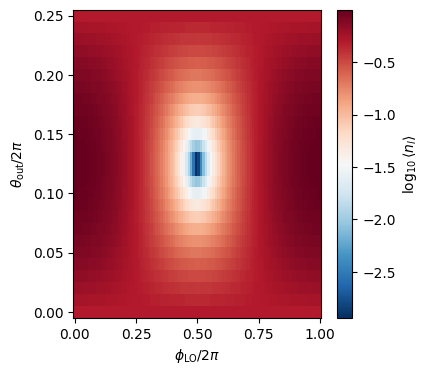

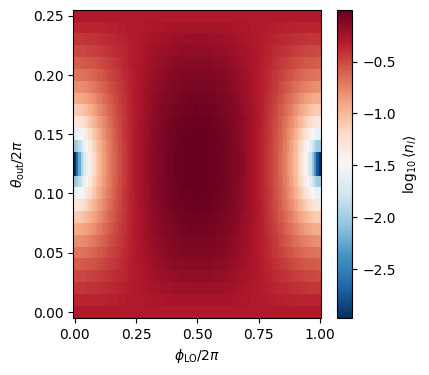

In [18]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

iU = 6
iG = 0

dat1 = np.log10(d_result['n1s'][iU, :, iG, :])
dat2 = np.log10(d_result['n2s'][iU, :, iG, :])
#dat = np.log10(d_result['g2_11s'][iU, :, iG, :])

x_axis = phi_LO / 2 / np.pi
y_axis = theta_outs / 2 / np.pi

# Diverging norm centered at 1
# norm = mcolors.TwoSlopeNorm(vmin=g2_min, vcenter=0.0, vmax=g2_max)

plt.figure(figsize=(4, 4))
plt.pcolormesh(x_axis, y_axis, dat1, cmap='RdBu_r')
plt.xlabel(r"$\phi_\text{LO}/2\pi$")
plt.ylabel(r"$\theta_\text{out}/2\pi$")
plt.colorbar(label=r"$\log_{10}\langle n_l\rangle$")
plt.show()

plt.figure(figsize=(4, 4))
plt.pcolormesh(x_axis, y_axis, dat2, cmap='RdBu_r')
plt.xlabel(r"$\phi_\text{LO}/2\pi$")
plt.ylabel(r"$\theta_\text{out}/2\pi$")
plt.colorbar(label=r"$\log_{10}\langle n_l\rangle$")
plt.show()

In [6]:
d_result['g2_11s'].shape

(10, 26, 10, 100)